# DL Astronomy

## Imports

In [10]:
import os

import kagglehub
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

## Dataset loading

In [24]:
path = kagglehub.dataset_download("anjosut/galaxy-zoo-classification")
label_filename = "train_label.csv"
label_filepath = os.path.join(path, label_filename)
df = pd.read_csv(label_filepath, names=["image_id", "label"])

## EDA

### Dataset analysis

In [25]:
df.head()

,image_id,label
0,100053,Class1
1,100122,Class1
2,100143,Class3
3,100288,Class1
4,100295,Class1


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28793 entries, 0 to 28792
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   image_id  28793 non-null  int64
 1   label     28793 non-null  str  
dtypes: int64(1), str(1)
memory usage: 450.0 KB


In [27]:
print(f"Images: {df.shape[0]}")

Images: 28793


### Target distribution

label
Class2    8436
Class1    8069
Class4    7806
Class3    3903
Class0     579
Name: count, dtype: int64


<Axes: xlabel='label', ylabel='count'>

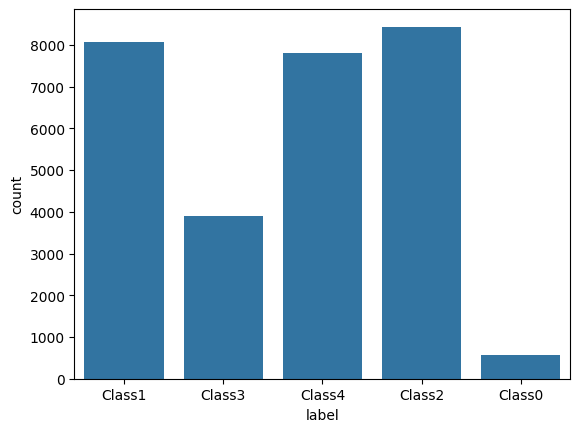

In [28]:
print(df["label"].value_counts())
sns.countplot(data=df, x="label")

### Sample images

"Cigar-shaped smooth" images: 579
"completely round smooth" images: 8436
"edge-on" images: 3903
"In between smooth" images: 8069
"spiral" images: 7806
Total images: 28793


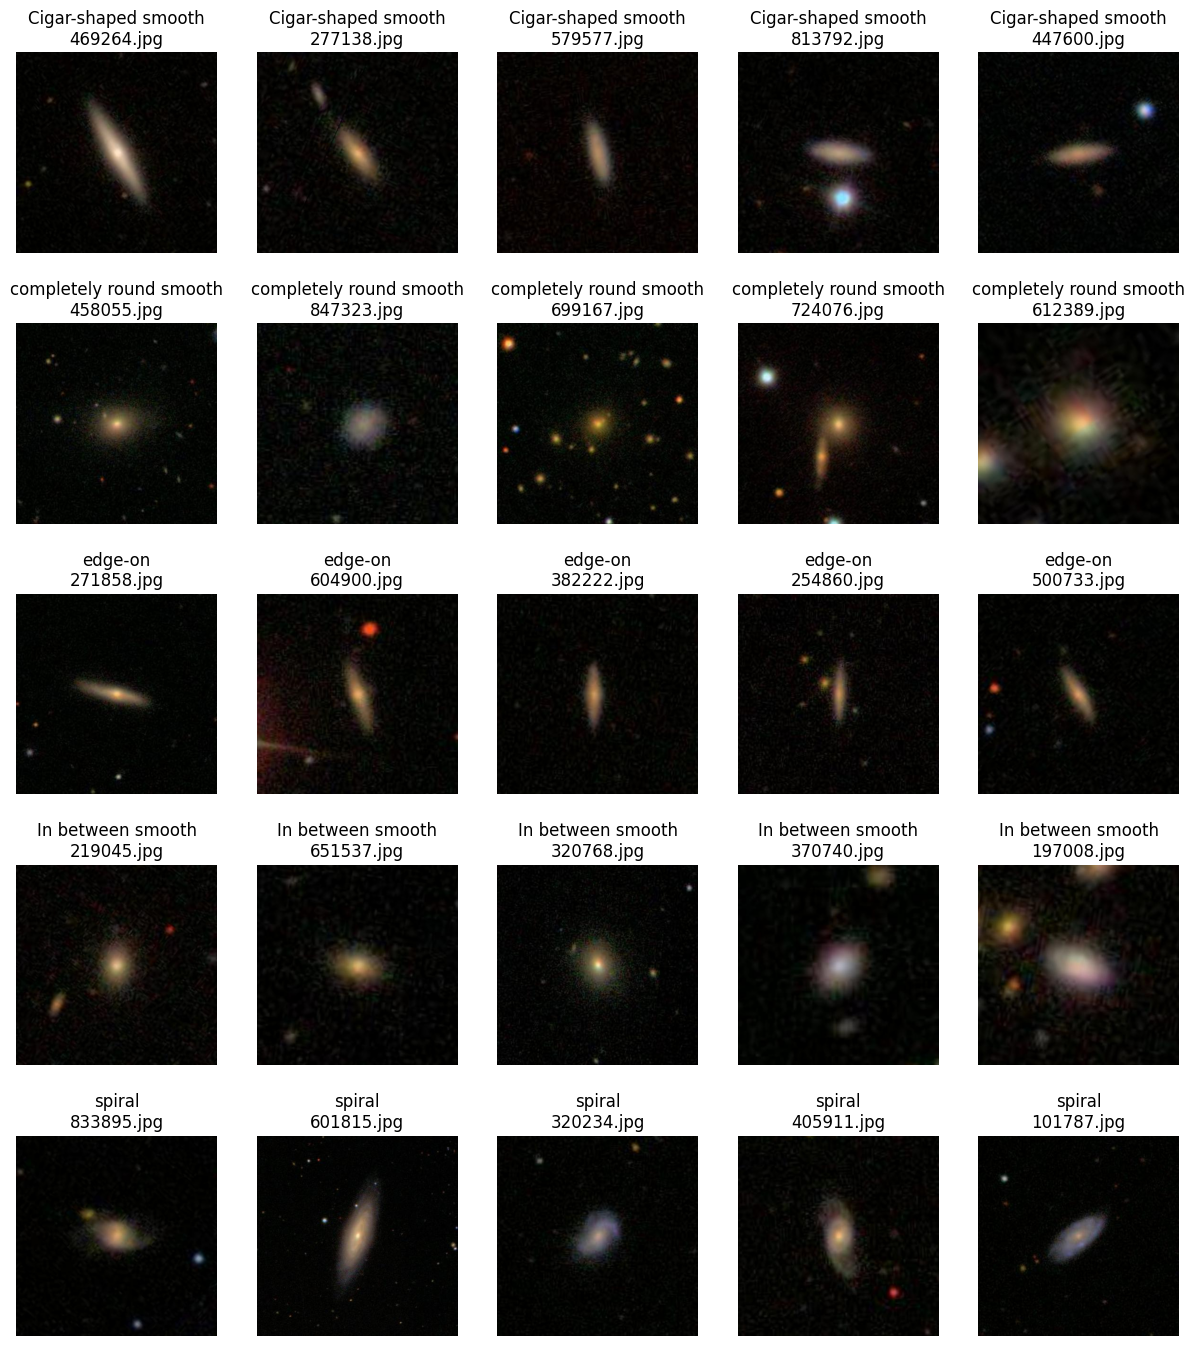

In [46]:
data_dir = Path(os.path.join(path, "Train_images", "Train_images"))

valid_classes = ["Cigar-shaped smooth", "completely round smooth", "edge-on", "In between smooth", "spiral"]

fig, axes = plt.subplots(len(valid_classes), 5, figsize=(15, 17))

total_images = 0

for i, class_name in enumerate(valid_classes):
    class_path = data_dir / class_name
    image_files = list(class_path.glob('*.jpg'))

    print(f"\"{class_name}\" images: {len(image_files)}")
    total_images += len(image_files)

    image_files = image_files[:5]
    
    for j, img_path in enumerate(image_files):
        img = plt.imread(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        axes[i, j].set_title(f"{class_name}\n{img_path.name}")
        if j == 0:
            axes[i, j].set_ylabel(class_name.upper(), fontsize=12, fontweight='bold', rotation=0, ha='right', va='center')

print(f"Total images: {total_images}")

### Label matching

In [ ]:
print("\"Cigar-shaped smooth\" label search:")
print(df[df["image_id"] == 469264]["label"])

print("\n\"completely round smooth\" label search:")
print(df[df["image_id"] == 458055]["label"])

print("\n\"edge-on\" label search:")
print(df[df["image_id"] == 271858]["label"])

print("\n\"In between smooth\" label search:")
print(df[df["image_id"] == 219045]["label"])

print("\n\"spiral\" label search:")
print(df[df["image_id"] == 833895]["label"])

"Cigar-shaped smooth" label search:
11821    Class0
Name: label, dtype: str

"completely round smooth" label search:
11480    Class2
Name: label, dtype: str

"edge-on" label search:
5455    Class3
Name: label, dtype: str

"In between smooth" label search:
3828    Class1
Name: label, dtype: str

"spiral" label search:
23580    Class4
Name: label, dtype: str
